#Importing Required Libraries

In [ ]:
path = '/content/oral_cancer_prediction_dataset (1).csv'

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')
sns.set_palette('Set2')
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PowerTransformer,StandardScaler
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,matthews_corrcoef

#Step 1 — Data Loading & Understanding


In [ ]:
df = pd.read_csv(path)
df.head()

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


In [ ]:
df.dtypes

,0
ID,int64
Country,object
Age,int64
Gender,object
Tobacco Use,object
Alcohol Consumption,object
HPV Infection,object
Betel Quid Use,object
Chronic Sun Exposure,object
Poor Oral Hygiene,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   ID                                        84922 non-null  int64  
 1   Country                                   84922 non-null  object 
 2   Age                                       84922 non-null  int64  
 3   Gender                                    84922 non-null  object 
 4   Tobacco Use                               84922 non-null  object 
 5   Alcohol Consumption                       84922 non-null  object 
 6   HPV Infection                             84922 non-null  object 
 7   Betel Quid Use                            84922 non-null  object 
 8   Chronic Sun Exposure                      84922 non-null  object 
 9   Poor Oral Hygiene                         84922 non-null  object 
 10  Diet (Fruits & Vegetables Intake) 

In [ ]:
df.isna().sum()

,0
ID,0
Country,0
Age,0
Gender,0
Tobacco Use,0
Alcohol Consumption,0
HPV Infection,0
Betel Quid Use,0
Chronic Sun Exposure,0
Poor Oral Hygiene,0


In [ ]:
df[df.duplicated()]

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)


In [ ]:
df.select_dtypes('number').columns.tolist()

['ID',
 'Age',
 'Tumor Size (cm)',
 'Cancer Stage',
 'Survival Rate (5-Year, %)',
 'Cost of Treatment (USD)',
 'Economic Burden (Lost Workdays per Year)']

In [ ]:
df.select_dtypes('object').columns.tolist()

['Country',
 'Gender',
 'Tobacco Use',
 'Alcohol Consumption',
 'HPV Infection',
 'Betel Quid Use',
 'Chronic Sun Exposure',
 'Poor Oral Hygiene',
 'Diet (Fruits & Vegetables Intake)',
 'Family History of Cancer',
 'Compromised Immune System',
 'Oral Lesions',
 'Unexplained Bleeding',
 'Difficulty Swallowing',
 'White or Red Patches in Mouth',
 'Treatment Type',
 'Early Diagnosis',
 'Oral Cancer (Diagnosis)']

In [ ]:
df.select_dtypes('bool').columns.tolist()

[]

In [ ]:
df.head()

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


In [ ]:
df.drop(['ID'],axis=1,inplace=True)

In [ ]:
df.head()

,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Diet (Fruits & Vegetables Intake),...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,Low,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,High,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,UK,37,Female,No,Yes,No,No,Yes,Yes,Moderate,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,Moderate,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,South Africa,68,Male,No,No,No,No,No,Yes,High,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


#Renaming the columns

In [ ]:
df.columns

Index(['Country', 'Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption',
       'HPV Infection', 'Betel Quid Use', 'Chronic Sun Exposure',
       'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)',
       'Family History of Cancer', 'Compromised Immune System', 'Oral Lesions',
       'Unexplained Bleeding', 'Difficulty Swallowing',
       'White or Red Patches in Mouth', 'Tumor Size (cm)', 'Cancer Stage',
       'Treatment Type', 'Survival Rate (5-Year, %)',
       'Cost of Treatment (USD)', 'Economic Burden (Lost Workdays per Year)',
       'Early Diagnosis', 'Oral Cancer (Diagnosis)'],
      dtype='object')

In [ ]:
rename_dict = {
    'Country': 'country',
    'Age': 'age',
    'Gender': 'gender',
    'Tobacco Use': 'tobacco_use',
    'Alcohol Consumption': 'alcohol_use',
    'HPV Infection': 'hpv_infection',
    'Betel Quid Use': 'betel_quid',
    'Chronic Sun Exposure': 'sun_exposure',
    'Poor Oral Hygiene': 'oral_hygiene',
    'Diet (Fruits & Vegetables Intake)': 'diet_intake',
    'Family History of Cancer': 'family_history',
    'Compromised Immune System': 'immune_status',
    'Oral Lesions': 'oral_lesions',
    'Unexplained Bleeding': 'bleeding',
    'Difficulty Swallowing': 'swallowing_difficulty',
    'White or Red Patches in Mouth': 'mouth_patches',
    'Tumor Size (cm)': 'tumor_size',
    'Cancer Stage': 'cancer_stage',
    'Treatment Type': 'treatment_type',
    'Survival Rate (5-Year, %)': 'survival_rate',
    'Cost of Treatment (USD)': 'treatment_cost',
    'Economic Burden (Lost Workdays per Year)': 'economic_burden',
    'Early Diagnosis': 'early_diagnosis',
    'Oral Cancer (Diagnosis)': 'diagnosis'
}

df.rename(columns=rename_dict, inplace=True)


In [ ]:
df.head()

,country,age,gender,tobacco_use,alcohol_use,hpv_infection,betel_quid,sun_exposure,oral_hygiene,diet_intake,...,swallowing_difficulty,mouth_patches,tumor_size,cancer_stage,treatment_type,survival_rate,treatment_cost,economic_burden,early_diagnosis,diagnosis
0,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,Low,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,High,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,UK,37,Female,No,Yes,No,No,Yes,Yes,Moderate,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,Moderate,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,South Africa,68,Male,No,No,No,No,No,Yes,High,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


#Step 2 — Exploratory Data Analysis (EDA)

In [ ]:
df['diagnosis'].value_counts()

,count
diagnosis,
No,42573
Yes,42349


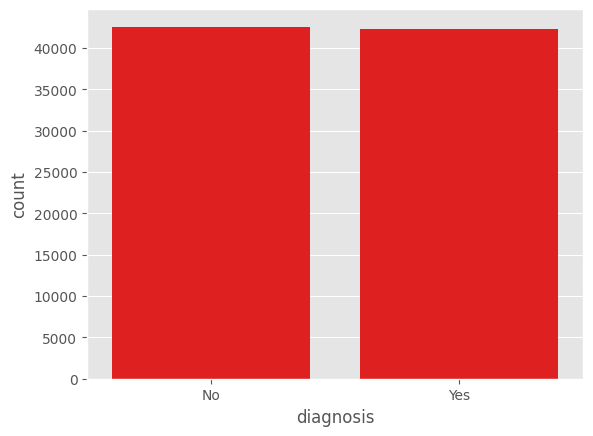

In [ ]:
sns.countplot(data=df,x = 'diagnosis',color='r')
plt.show()

In [ ]:
num_cols = df.select_dtypes('number').columns.tolist()

num_cols

['age',
 'tumor_size',
 'cancer_stage',
 'survival_rate',
 'treatment_cost',
 'economic_burden']

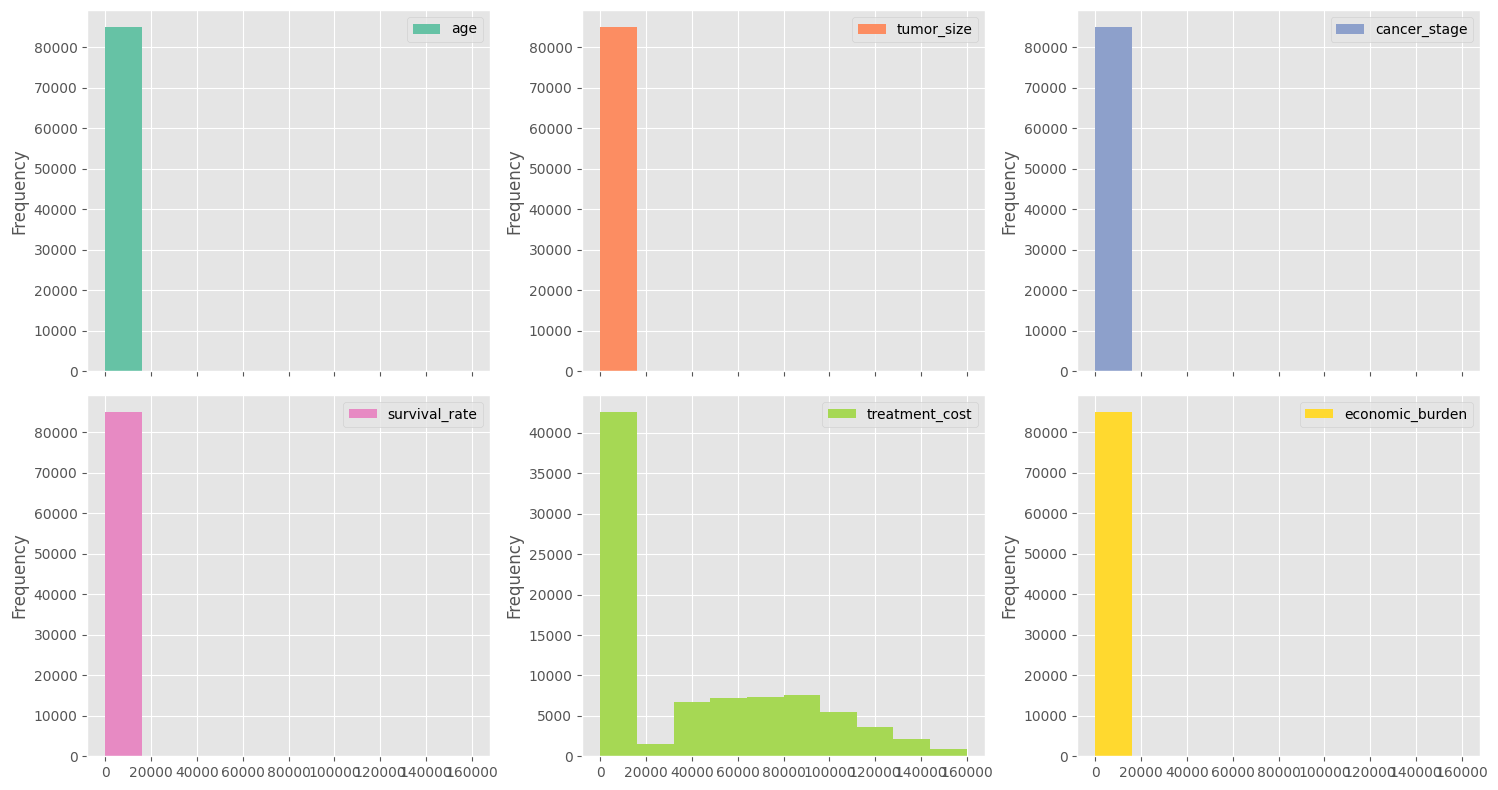

In [ ]:
df[num_cols].plot(kind='hist',subplots=True,layout = (2,3),figsize=(15,8))
plt.tight_layout()
plt.show()

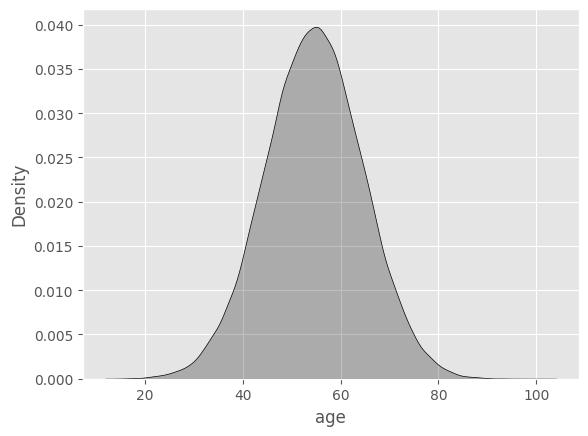

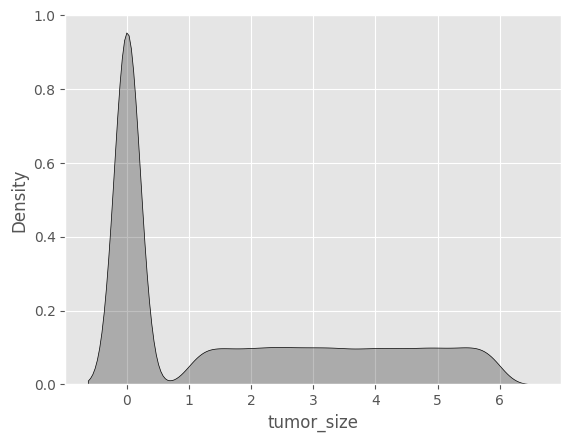

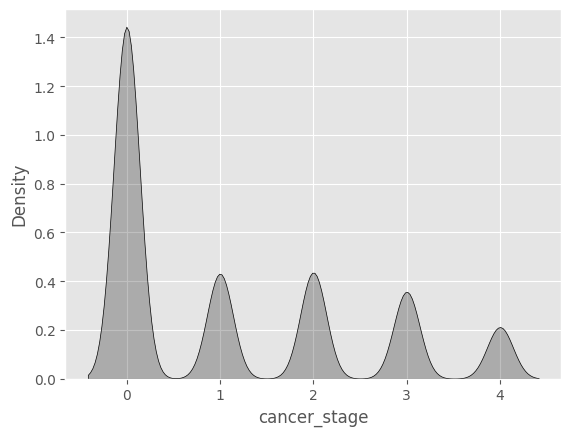

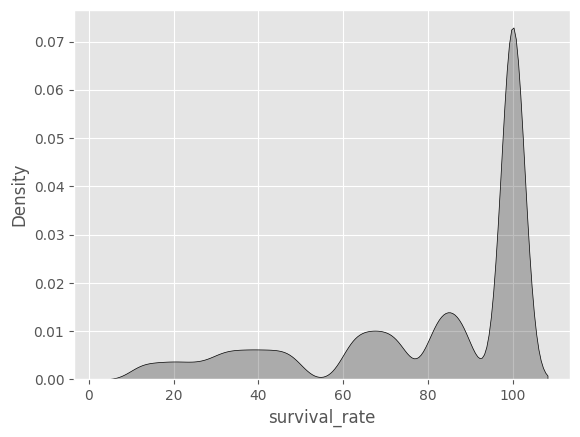

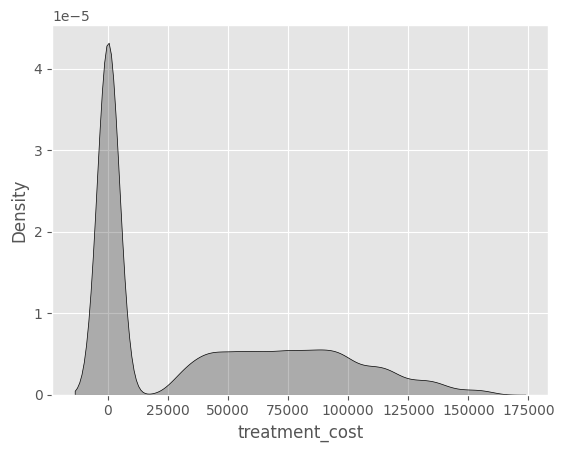

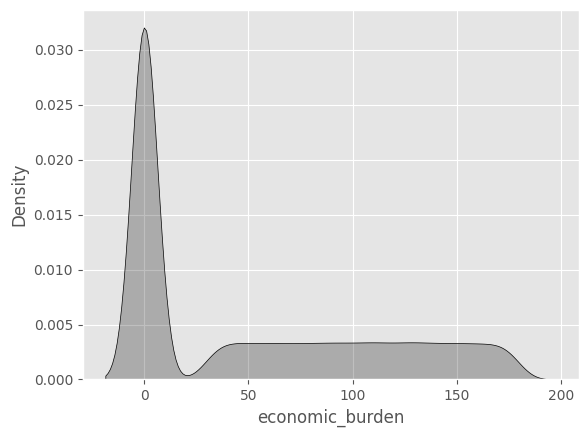

In [ ]:
for col in num_cols:
  sns.kdeplot(df[col],fill=True,color='k')
  plt.show()

- Looking at the kde plots we can clearly see the features other than the age are skewed in nature and need to be fixed using transformations

In [ ]:
df[num_cols].skew()

,0
age,-0.020433
tumor_size,0.663231
cancer_stage,0.825012
survival_rate,-1.078983
treatment_cost,0.668452
economic_burden,0.663021


In [ ]:
df[num_cols].kurtosis()

,0
age,0.020594
tumor_size,-1.067805
cancer_stage,-0.676291
survival_rate,-0.139701
treatment_cost,-0.884191
economic_burden,-1.066582


#Using Transformations to fix skewness & kurtosis

In [ ]:
num_cols

['age',
 'tumor_size',
 'cancer_stage',
 'survival_rate',
 'treatment_cost',
 'economic_burden']

In [ ]:
"""pt = PowerTransformer(method = 'yeo-johnson')
df[num_cols[1:]] = pt.fit_transform(df[num_cols[1:]])"""

"pt = PowerTransformer(method = 'yeo-johnson')\ndf[num_cols[1:]] = pt.fit_transform(df[num_cols[1:]])"

In [ ]:
df.head()

,country,age,gender,tobacco_use,alcohol_use,hpv_infection,betel_quid,sun_exposure,oral_hygiene,diet_intake,...,swallowing_difficulty,mouth_patches,tumor_size,cancer_stage,treatment_type,survival_rate,treatment_cost,economic_burden,early_diagnosis,diagnosis
0,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,Low,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,High,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,UK,37,Female,No,Yes,No,No,Yes,Yes,Moderate,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,Moderate,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,South Africa,68,Male,No,No,No,No,No,Yes,High,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


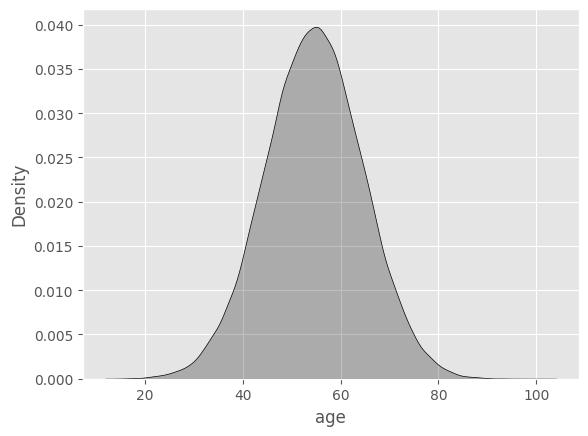

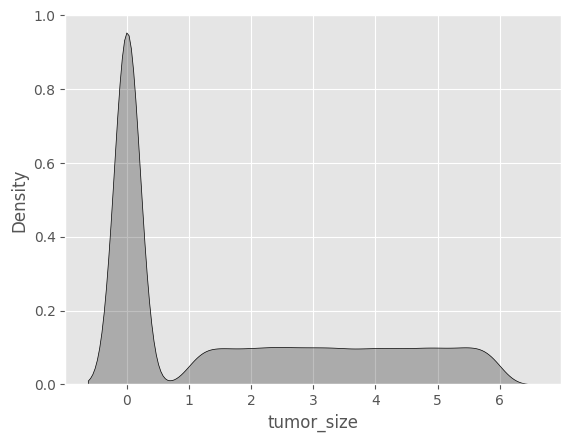

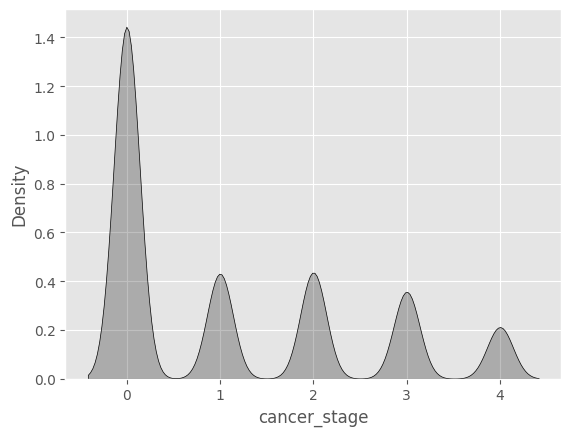

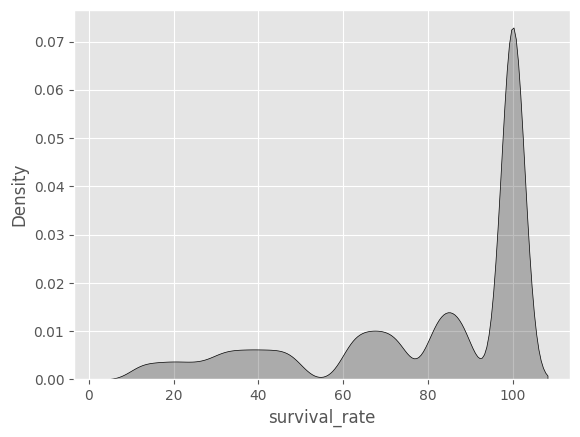

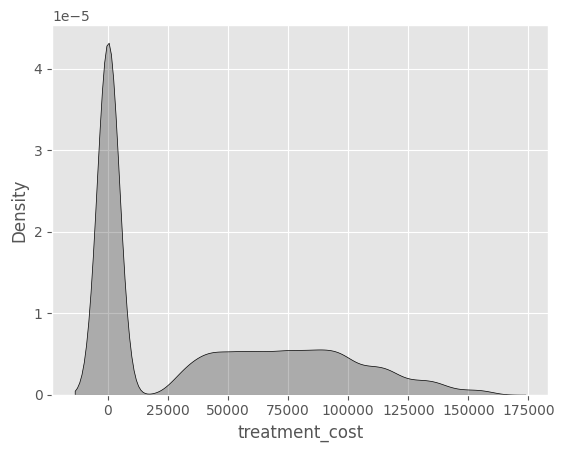

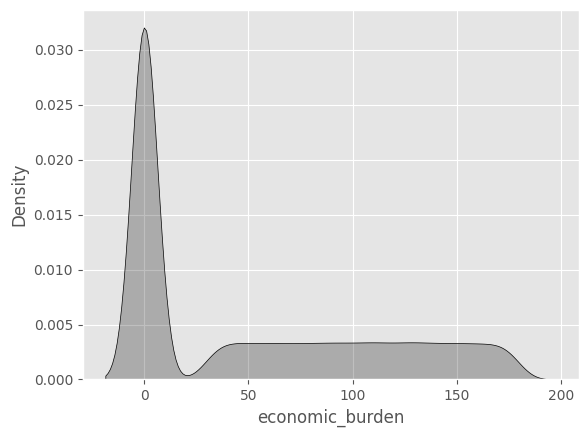

In [ ]:
for col in num_cols:
  sns.kdeplot(df[col],fill=True,color='k')
  plt.show()

In [ ]:
df['tumor_size'].describe()

,tumor_size
count,84922.000000
mean,1.747294
std,2.028199
min,0.000000
25%,0.000000
50%,0.000000
75%,3.480075
max,5.999899


In [ ]:
num_cols

['age',
 'tumor_size',
 'cancer_stage',
 'survival_rate',
 'treatment_cost',
 'economic_burden']

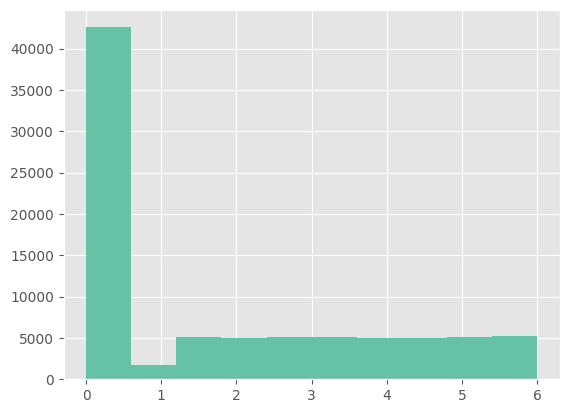

In [ ]:
((df['tumor_size'])).hist()  #we tried applying square, cube ,sqrt ,cbrt,etc
plt.show()

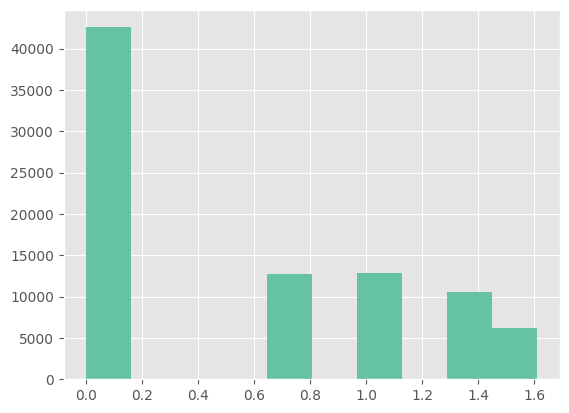

In [ ]:
(np.log1p(df['cancer_stage'])).hist()  #we tried applying square, cube ,sqrt ,cbrt,etc
plt.show()

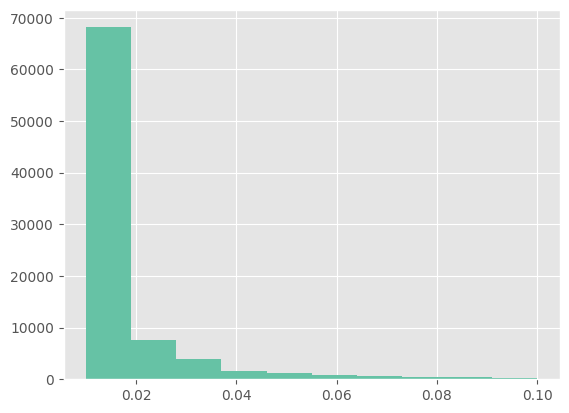

In [ ]:
((1/df['survival_rate'])).hist()
plt.show()

- we tried all the possible transformations on the features but the features dont tend to change the shape to a normal distribution



In [ ]:
df.head()

,country,age,gender,tobacco_use,alcohol_use,hpv_infection,betel_quid,sun_exposure,oral_hygiene,diet_intake,...,swallowing_difficulty,mouth_patches,tumor_size,cancer_stage,treatment_type,survival_rate,treatment_cost,economic_burden,early_diagnosis,diagnosis
0,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,Low,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,High,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,UK,37,Female,No,Yes,No,No,Yes,Yes,Moderate,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,Moderate,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,South Africa,68,Male,No,No,No,No,No,Yes,High,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


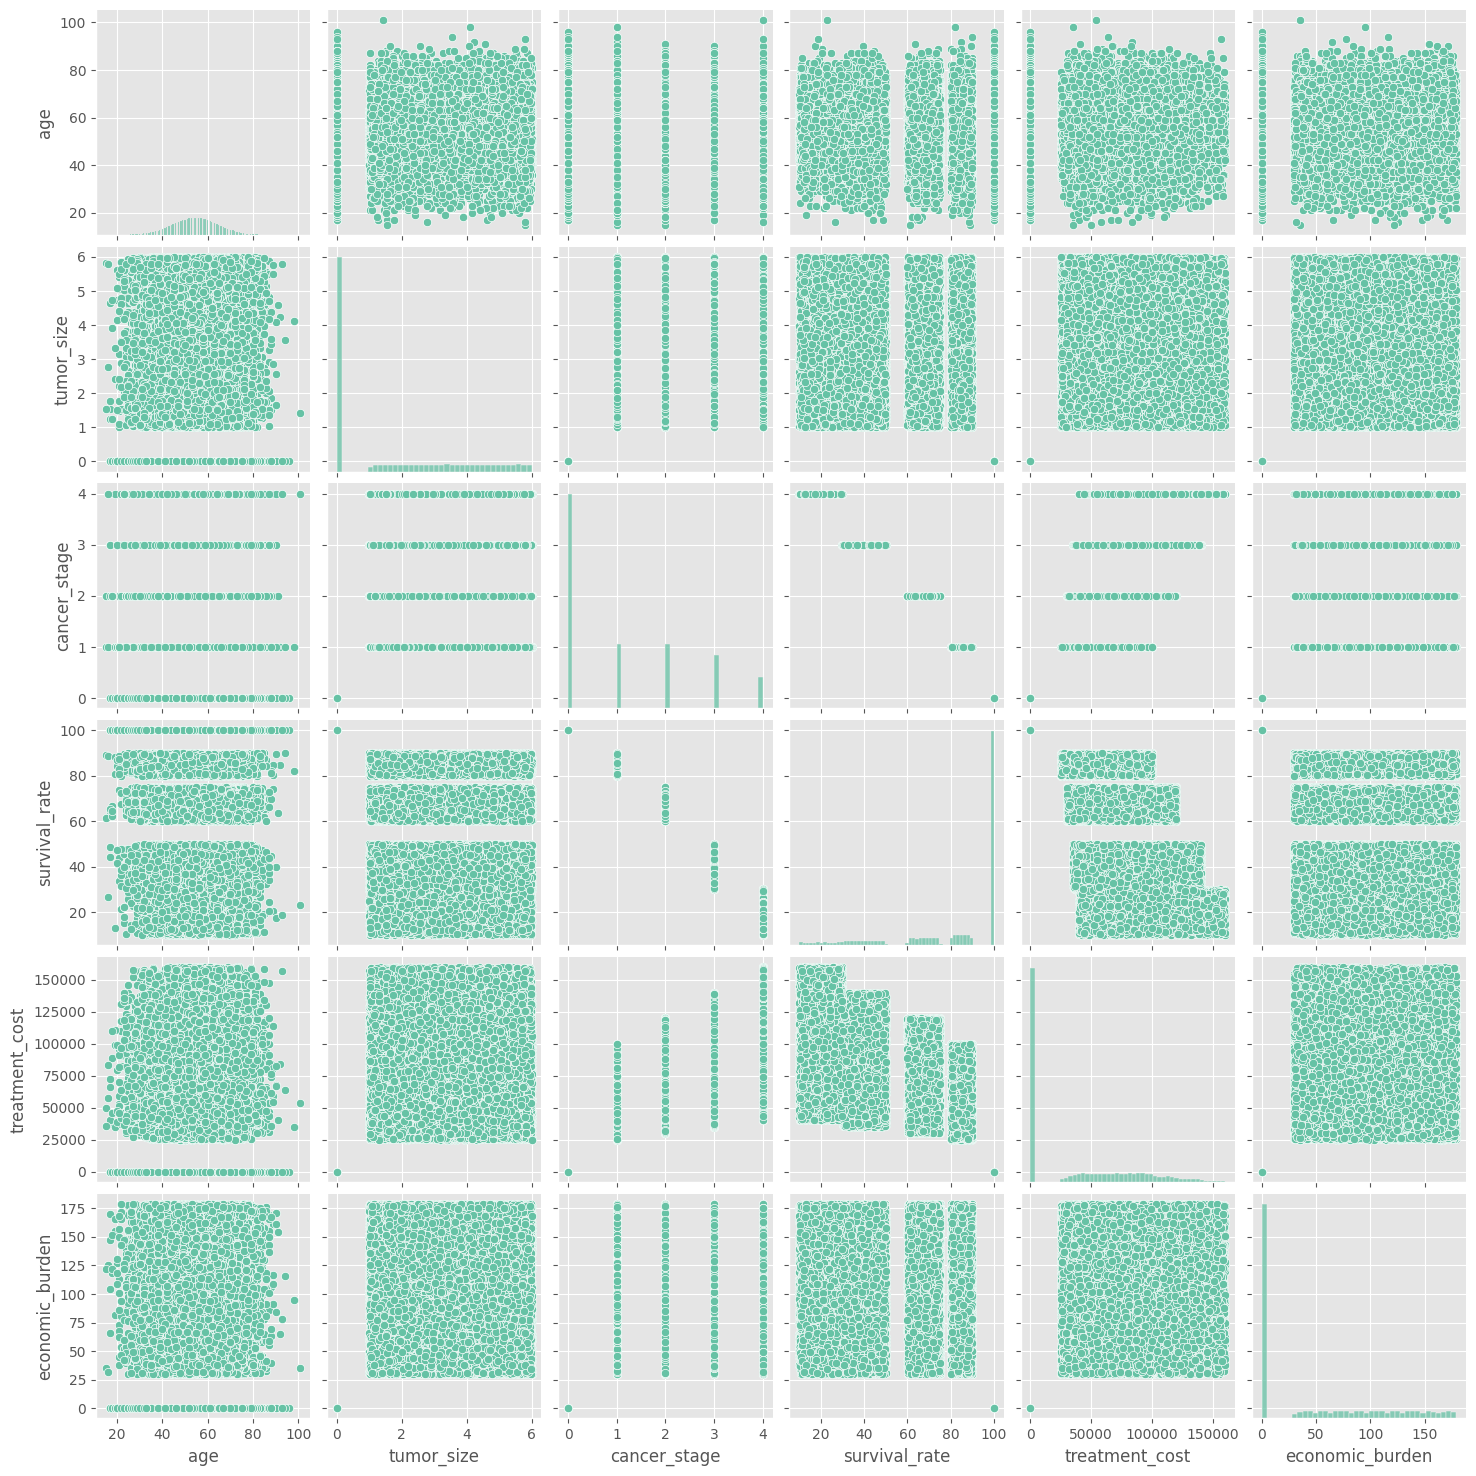

In [ ]:
sns.pairplot(df[num_cols])
plt.show()

#Age vs Diagnosis

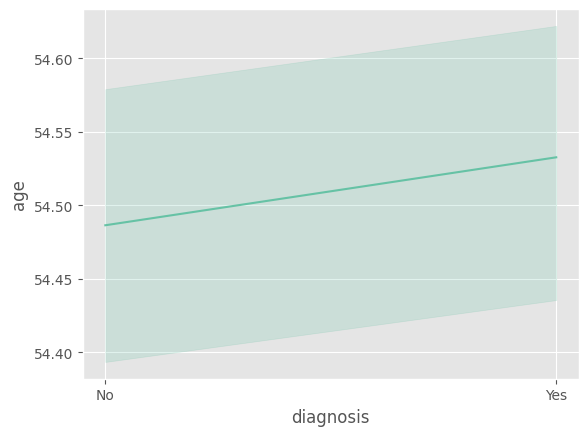

In [ ]:
sns.lineplot(data=df,x = 'diagnosis',y='age')
plt.show()

In [ ]:
df.groupby(['diagnosis'])['age'].mean()

,age
diagnosis,
No,54.486388
Yes,54.532622


In [ ]:
df.groupby(['diagnosis'])[num_cols].mean()

,age,tumor_size,cancer_stage,survival_rate,treatment_cost,economic_burden
diagnosis,,,,,,
No,54.486388,0.000000,0.00000,100.000000,0.000000,0.00000
Yes,54.532622,3.503831,2.24343,58.898313,78426.629554,104.33198


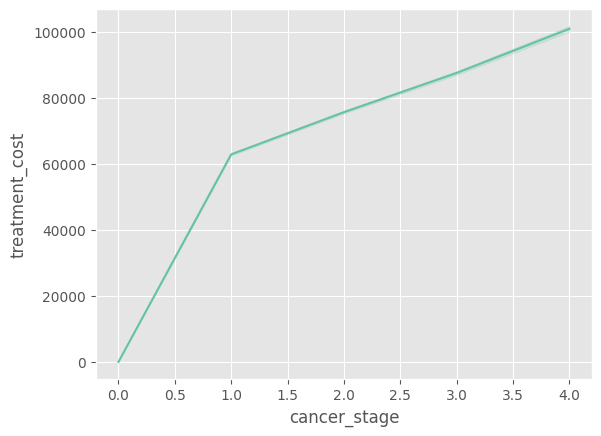

In [ ]:
sns.lineplot(data = df,x = 'cancer_stage',y = 'treatment_cost')
plt.show()

In [ ]:
df.head()

,country,age,gender,tobacco_use,alcohol_use,hpv_infection,betel_quid,sun_exposure,oral_hygiene,diet_intake,...,swallowing_difficulty,mouth_patches,tumor_size,cancer_stage,treatment_type,survival_rate,treatment_cost,economic_burden,early_diagnosis,diagnosis
0,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,Low,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,High,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,UK,37,Female,No,Yes,No,No,Yes,Yes,Moderate,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,Moderate,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,South Africa,68,Male,No,No,No,No,No,Yes,High,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


#Tobacco use vs Diagnosis

In [ ]:
pd.crosstab(df['tobacco_use'],df['diagnosis'])

diagnosis,No,Yes
tobacco_use,,
No,8521,8412
Yes,34052,33937


In [ ]:
df.groupby(['tobacco_use'])['diagnosis'].value_counts(normalize=True)*100

tobacco_use  diagnosis
No           No           50.321857
             Yes          49.678143
Yes          No           50.084573
             Yes          49.915427
Name: proportion, dtype: float64

#Step 3 — Outlier Detection & Handling

In [ ]:
num_cols

['age',
 'tumor_size',
 'cancer_stage',
 'survival_rate',
 'treatment_cost',
 'economic_burden']

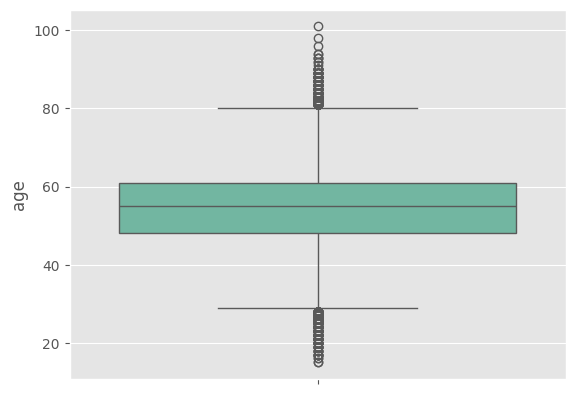

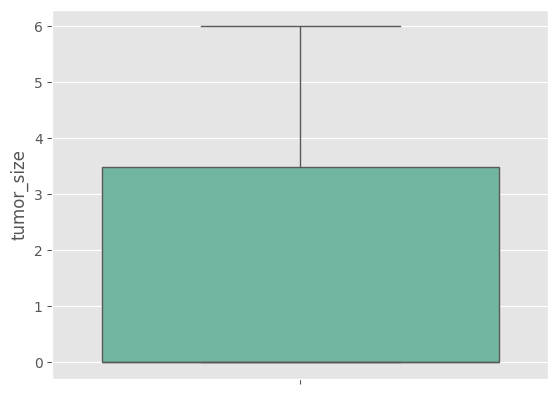

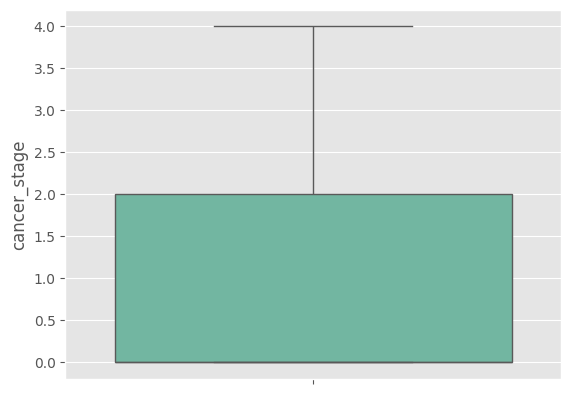

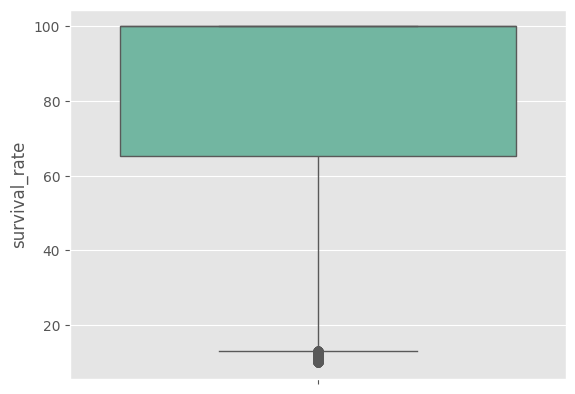

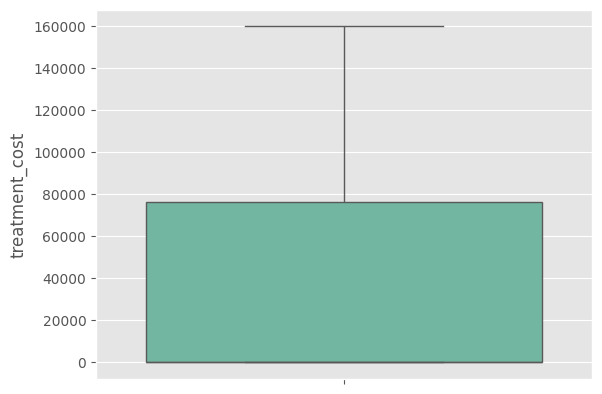

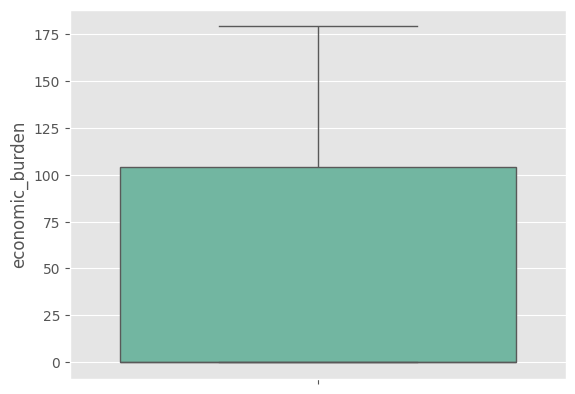

In [ ]:
for col in num_cols:
  sns.boxplot(df[col])
  plt.show()

- Looking at the boxplots we can see the age has outliers as per the boxplots but the age range is between 0 and 100 and that makes proper sense because people live to that age

In [ ]:
df[df['age']>100]

,country,age,gender,tobacco_use,alcohol_use,hpv_infection,betel_quid,sun_exposure,oral_hygiene,diet_intake,...,swallowing_difficulty,mouth_patches,tumor_size,cancer_stage,treatment_type,survival_rate,treatment_cost,economic_burden,early_diagnosis,diagnosis
59859,Germany,101,Male,No,Yes,Yes,No,No,Yes,Moderate,...,Yes,No,1.429667,4,Radiation,23.008071,53480.0,35,No,Yes


#Step 4 — Data Preprocessing


In [ ]:
cat_cols = df.select_dtypes('object').columns.to_list()

for col in cat_cols:
  print(col  ,   df[col].unique())

country ['Italy' 'Japan' 'UK' 'Sri Lanka' 'South Africa' 'Taiwan' 'USA' 'Germany'
 'France' 'Australia' 'Brazil' 'Pakistan' 'Kenya' 'Russia' 'Nigeria'
 'Egypt' 'India']
gender ['Female' 'Male']
tobacco_use ['Yes' 'No']
alcohol_use ['Yes' 'No']
hpv_infection ['Yes' 'No']
betel_quid ['No' 'Yes']
sun_exposure ['No' 'Yes']
oral_hygiene ['Yes' 'No']
diet_intake ['Low' 'High' 'Moderate']
family_history ['No' 'Yes']
immune_status ['No' 'Yes']
oral_lesions ['No' 'Yes']
bleeding ['No' 'Yes']
swallowing_difficulty ['No' 'Yes']
mouth_patches ['No' 'Yes']
treatment_type ['No Treatment' 'Surgery' 'Radiation' 'Targeted Therapy' 'Chemotherapy']
early_diagnosis ['No' 'Yes']
diagnosis ['No' 'Yes']


In [ ]:
mappings = {
    'country': {'Italy':0, 'Japan':1, 'UK':2, 'Sri Lanka':3, 'South Africa':4, 'Taiwan':5, 'USA':6,
                'Germany':7, 'France':8, 'Australia':9, 'Brazil':10, 'Pakistan':11, 'Kenya':12,
                'Russia':13, 'Nigeria':14, 'Egypt':15, 'India':16},

    'gender': {'Female':0, 'Male':1},

    'tobacco_use': {'No':0, 'Yes':1},
    'alcohol_use': {'No':0, 'Yes':1},
    'hpv_infection': {'No':0, 'Yes':1},
    'betel_quid': {'No':0, 'Yes':1},
    'sun_exposure': {'No':0, 'Yes':1},
    'oral_hygiene': {'No':0, 'Yes':1},
    'diet_intake': {'Low':0, 'Moderate':1, 'High':2},
    'family_history': {'No':0, 'Yes':1},
    'immune_status': {'No':0, 'Yes':1},
    'oral_lesions': {'No':0, 'Yes':1},
    'bleeding': {'No':0, 'Yes':1},
    'swallowing_difficulty': {'No':0, 'Yes':1},
    'mouth_patches': {'No':0, 'Yes':1},
    'treatment_type': {'No Treatment':0, 'Surgery':1, 'Radiation':2, 'Targeted Therapy':3, 'Chemotherapy':4},
    'early_diagnosis': {'No':0, 'Yes':1},
    'diagnosis': {'No':0, 'Yes':1}
}


for col, mapping in mappings.items():
    df[col] = df[col].map(mapping)

In [ ]:
df.head()

,country,age,gender,tobacco_use,alcohol_use,hpv_infection,betel_quid,sun_exposure,oral_hygiene,diet_intake,...,swallowing_difficulty,mouth_patches,tumor_size,cancer_stage,treatment_type,survival_rate,treatment_cost,economic_burden,early_diagnosis,diagnosis
0,0,36,0,1,1,1,0,0,1,0,...,0,0,0.000000,0,0,100.000000,0.00,0,0,0
1,1,64,1,1,1,1,0,1,1,2,...,0,0,1.782186,1,0,83.340103,77772.50,177,0,1
2,2,37,0,0,1,0,0,1,1,1,...,0,1,3.523895,2,1,63.222871,101164.50,130,1,1
3,3,55,1,1,1,0,1,0,1,1,...,0,0,0.000000,0,0,100.000000,0.00,0,1,0
4,4,68,1,0,0,0,0,0,1,2,...,0,0,2.834789,3,0,44.293199,45354.75,52,0,1


In [ ]:
df.select_dtypes('object')

""
0
1
2
3
4
...
84917
84918
84919
84920


In [ ]:
df.head()

,country,age,gender,tobacco_use,alcohol_use,hpv_infection,betel_quid,sun_exposure,oral_hygiene,diet_intake,...,swallowing_difficulty,mouth_patches,tumor_size,cancer_stage,treatment_type,survival_rate,treatment_cost,economic_burden,early_diagnosis,diagnosis
0,0,36,0,1,1,1,0,0,1,0,...,0,0,0.000000,0,0,100.000000,0.00,0,0,0
1,1,64,1,1,1,1,0,1,1,2,...,0,0,1.782186,1,0,83.340103,77772.50,177,0,1
2,2,37,0,0,1,0,0,1,1,1,...,0,1,3.523895,2,1,63.222871,101164.50,130,1,1
3,3,55,1,1,1,0,1,0,1,1,...,0,0,0.000000,0,0,100.000000,0.00,0,1,0
4,4,68,1,0,0,0,0,0,1,2,...,0,0,2.834789,3,0,44.293199,45354.75,52,0,1


In [ ]:
x = df.iloc[:,:-1]
y = df['diagnosis']

In [ ]:
df.shape

(84922, 24)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [ ]:
x_train.shape

(59445, 23)

In [ ]:
y_train.shape

(59445,)

In [ ]:
x_test.shape

(25477, 23)

In [ ]:
y_test.shape

(25477,)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
x_train.mean(axis=0)

array([-1.05693904e-16, -3.54882897e-16,  3.23924773e-17,  1.78816037e-16,
        3.89068316e-17, -4.37477738e-17, -1.78098861e-17,  4.69750686e-17,
       -1.05903081e-16,  4.24329500e-17, -5.49835408e-18,  1.66743564e-17,
       -4.35087149e-17,  8.45670764e-18, -8.45670764e-17, -7.29129563e-17,
        1.96745453e-16, -2.45035345e-18,  4.07595379e-17, -4.56482918e-16,
       -2.18738869e-17,  1.09967082e-17, -2.82687118e-17])

In [ ]:
x_train.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1.])

#Step 5 — Model Building

In [ ]:
log_reg = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
knn = KNeighborsClassifier()
xgb = XGBClassifier()

models = [log_reg,dt,rf,knn,xgb]
models

[LogisticRegression(),
 DecisionTreeClassifier(),
 RandomForestClassifier(),
 KNeighborsClassifier(),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...)]

In [ ]:

scores = []
for model in models:
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test,y_pred)
  p = precision_score(y_test,y_pred)
  r = recall_score(y_test,y_pred)
  f = f1_score(y_test,y_pred)
  mcc = matthews_corrcoef(y_test,y_pred)
  cm = confusion_matrix(y_test,y_pred)


  print(model.__class__.__name__,cm)


  scores.append((model.__class__.__name__,acc,p,r,f,mcc))


LogisticRegression [[12747     0]
 [    0 12730]]
DecisionTreeClassifier [[12747     0]
 [    0 12730]]
RandomForestClassifier [[12747     0]
 [    0 12730]]
KNeighborsClassifier [[12747     0]
 [  110 12620]]
XGBClassifier [[12747     0]
 [    0 12730]]


| Model                  | Accuracy | Precision | Recall   | F1_Score | ROC_AUC  |
| ---------------------- | -------- | --------- | -------- | -------- | -------- |
| LogisticRegression     | 1.000000 | 1.000000  | 1.000000 | 1.000000 | 1.000000 |
| DecisionTreeClassifier | 1.000000 | 1.000000  | 1.000000 | 1.000000 | 1.000000 |
| RandomForestClassifier | 1.000000 | 1.000000  | 1.000000 | 1.000000 | 1.000000 |
| KNeighborsClassifier   | 0.995682 | 1.000000  | 0.991359 | 0.995661 | 0.991402 |
| XGBClassifier          | 1.000000 | 1.000000  | 1.000000 | 1.000000 | 1.000000 |


- based on the scores results we choose rfc as the best model as we also  have other models but choosing rfc for interpretability purpose

In [ ]:
rfc = RandomForestClassifier()
rfc.fit(x_train,y_train)

y_pred = rfc.predict(x_test)
y_pred[:10]

array([1, 0, 0, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
y_test.values[:10]

array([1, 0, 0, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
acc = accuracy_score(y_test,y_pred)
p = precision_score(y_test,y_pred)
r = recall_score(y_test,y_pred)
f = f1_score(y_test,y_pred)
mcc = matthews_corrcoef(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)

# print formatted output
print("Model Evaluation Metrics")
print("------------------------")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1 Score: {f:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")
print("\nConfusion Matrix:")
print(cm)

Model Evaluation Metrics
------------------------
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Matthews Correlation Coefficient: 1.0000

Confusion Matrix:
[[12747     0]
 [    0 12730]]


#Step 8 — Feature Importance & Interpretation

In [ ]:
rfc.feature_importances_

array([1.48458393e-05, 2.17049211e-05, 2.38253394e-06, 9.01482495e-07,
       1.67072365e-06, 1.25468747e-06, 5.23819803e-07, 1.93720779e-06,
       1.58379789e-06, 3.69948285e-06, 7.32753109e-07, 2.90477646e-06,
       1.69642885e-06, 2.15445132e-06, 1.56214691e-06, 5.01889726e-08,
       2.20946253e-01, 1.99055041e-01, 7.00464136e-02, 1.83723043e-01,
       1.53362128e-01, 1.72806357e-01, 1.15992301e-06])

In [ ]:
x.columns

Index(['country', 'age', 'gender', 'tobacco_use', 'alcohol_use',
       'hpv_infection', 'betel_quid', 'sun_exposure', 'oral_hygiene',
       'diet_intake', 'family_history', 'immune_status', 'oral_lesions',
       'bleeding', 'swallowing_difficulty', 'mouth_patches', 'tumor_size',
       'cancer_stage', 'treatment_type', 'survival_rate', 'treatment_cost',
       'economic_burden', 'early_diagnosis'],
      dtype='object')

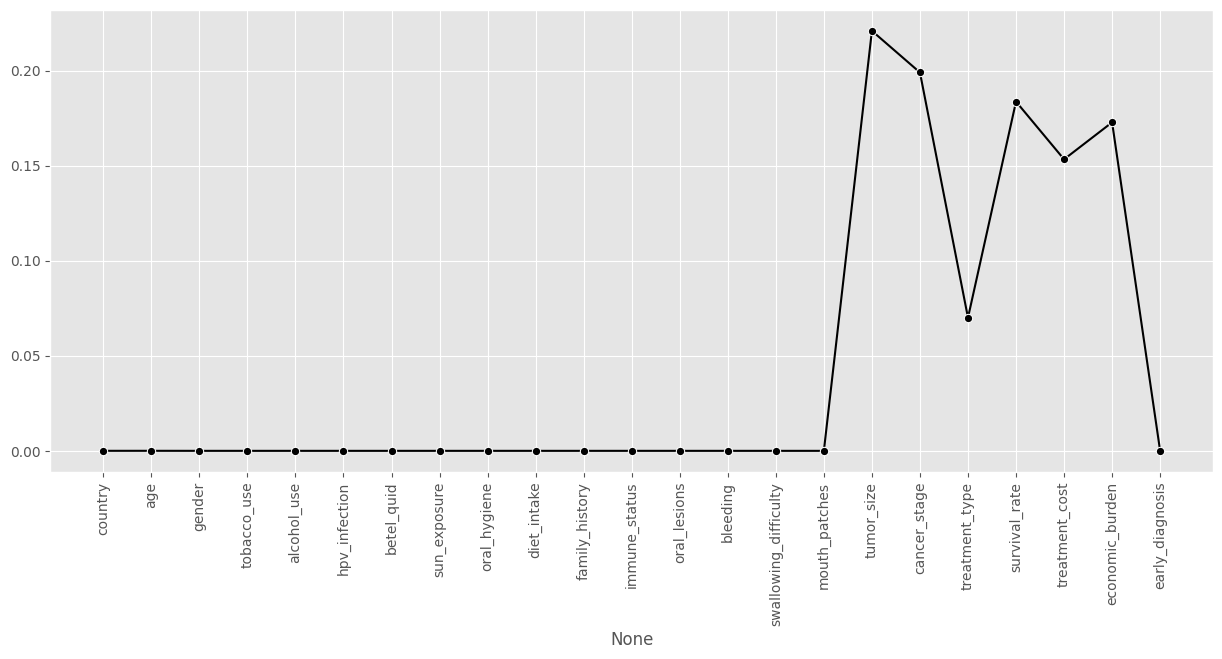

In [ ]:
plt.figure(figsize=(15,6))
sns.lineplot(x = x.columns,y = rfc.feature_importances_,marker = 'o',color='k')
plt.xticks(rotation=90)
plt.show()

In [ ]:
results_df = pd.DataFrame()

results_df['Features'] = x.columns
results_df['Importance'] = rfc.feature_importances_

results_df.sort_values(by='Importance',ascending=False).head(10)

,Features,Importance
16,tumor_size,0.220946
17,cancer_stage,0.199055
19,survival_rate,0.183723
21,economic_burden,0.172806
20,treatment_cost,0.153362
18,treatment_type,0.070046
1,age,0.000022
0,country,0.000015
9,diet_intake,0.000004
11,immune_status,0.000003


In [ ]:
results_df.sort_values(by='Importance',ascending=False).head(10)['Features'].values

array(['tumor_size', 'cancer_stage', 'survival_rate', 'economic_burden',
       'treatment_cost', 'treatment_type', 'age', 'country',
       'diet_intake', 'immune_status'], dtype=object)

#Using the Top 10 Features create a new RFC Model and evaluate it

In [ ]:
x = df[['tumor_size', 'cancer_stage', 'survival_rate', 'economic_burden',
       'treatment_cost', 'treatment_type', 'age', 'country',
       'diet_intake', 'immune_status']]

y = df['diagnosis']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [ ]:
rfc_10 = RandomForestClassifier()
rfc_10.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred = rfc_10.predict(x_test)

acc = accuracy_score(y_test,y_pred)
p = precision_score(y_test,y_pred)
r = recall_score(y_test,y_pred)
f = f1_score(y_test,y_pred)
mcc = matthews_corrcoef(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)

# print formatted output
print("Model Evaluation Metrics")
print("------------------------")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1 Score: {f:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")
print("\nConfusion Matrix:")
print(cm)

Model Evaluation Metrics
------------------------
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Matthews Correlation Coefficient: 1.0000

Confusion Matrix:
[[12700     0]
 [    0 12777]]


In [ ]:
df[['tumor_size', 'cancer_stage', 'survival_rate', 'economic_burden',
       'treatment_cost', 'treatment_type', 'age', 'country',
       'diet_intake', 'immune_status','diagnosis']].sample(1)

,tumor_size,cancer_stage,survival_rate,economic_burden,treatment_cost,treatment_type,age,country,diet_intake,immune_status,diagnosis
56138,2.587986,4,28.876876,94,72950.0,1,41,6,0,1,1


In [ ]:
test = [[2.587986	,4	,28.876876	,94	,72950.0	,1,	41	,6	,0	,1]]
test = scaler.transform(test)

rfc_10.predict(test)

array([1])

#Save the final model using Pickle Library in Python.

In [ ]:
import pickle

with open('rfc_10.pkl','wb') as f:
  pickle.dump(rfc_10,f)

In [ ]:
with open('/content/rfc_10.pkl','rb') as f:
  loaded_model = pickle.load(f)



In [ ]:
test = [[2.587986	,4	,28.876876	,94	,72950.0	,1,	41	,6	,0	,1]]
test = scaler.transform(test)

loaded_model.predict(test)

array([1])